In [1]:
import torch
import numpy as np
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [2]:
import pandas as pd

# Load BTC CSV
bnb_df = pd.read_csv(r'feature_datasets\BNB_features.csv', parse_dates=True, index_col=0)

# Define X and y
bnb_y = bnb_df['Close'].shift(-1)          # next-day close price
bnb_X = bnb_df.drop(columns=['Close'])     # all other features

# Drop last row (y will be NaN)
bnb_X = bnb_X.iloc[:-1]
bnb_y = bnb_y.iloc[:-1]

# Optional: check shapes
print("BNB X shape:", bnb_X.shape)
print("BNB y shape:", bnb_y.shape)

BNB X shape: (915, 29)
BNB y shape: (915,)


## 70-30 split

In [3]:
# 70% train / 30% test split (time-based)
split_idx = int(len(bnb_X) * 0.7)

bnb_X_train = bnb_X.iloc[:split_idx].values
bnb_X_test  = bnb_X.iloc[split_idx:].values

bnb_y_train = bnb_y.iloc[:split_idx].values
bnb_y_test  = bnb_y.iloc[split_idx:].values

# check shapes
print("BNB X_train shape:", bnb_X_train.shape)
print("BNB X_test shape:", bnb_X_test.shape)
print("BNB y_train shape:", bnb_y_train.shape)
print("BNB y_test shape:", bnb_y_test.shape)

BNB X_train shape: (640, 29)
BNB X_test shape: (275, 29)
BNB y_train shape: (640,)
BNB y_test shape: (275,)


In [4]:
bnb_test_dates = bnb_df.index[-len(bnb_X_test):]  # get the dates for test set

In [5]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Initialize scaler
scaler = MinMaxScaler()

# Fit on TRAIN only
bnb_X_train_scaled = scaler.fit_transform(bnb_X_train)

# Transform TEST using the same scaler
bnb_X_test_scaled = scaler.transform(bnb_X_test)

# Check shapes
print("Scaled X_train shape:", bnb_X_train_scaled.shape)
print("Scaled X_test shape:", bnb_X_test_scaled.shape)

Scaled X_train shape: (640, 29)
Scaled X_test shape: (275, 29)


In [6]:
# Initialize scaler for y
y_scaler = MinMaxScaler()

# Scale training target
bnb_y_train_scaled = y_scaler.fit_transform(bnb_y_train.reshape(-1,1)).flatten()

# Scale test target
bnb_y_test_scaled = y_scaler.transform(bnb_y_test.reshape(-1,1)).flatten()

In [7]:
def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])  # the next day after the sequence
    return np.array(X_seq), np.array(y_seq)

# Create sequences for BNB using scaled target
bnb_X_train_seq, bnb_y_train_seq = create_sequences(bnb_X_train_scaled, bnb_y_train_scaled, time_steps=30)
bnb_X_test_seq, bnb_y_test_seq = create_sequences(bnb_X_test_scaled, bnb_y_test_scaled, time_steps=30)

# Check shapes
print("BNB X_train_seq shape:", bnb_X_train_seq.shape)
print("BNB y_train_seq shape:", bnb_y_train_seq.shape)
print("BNB X_test_seq shape:", bnb_X_test_seq.shape)
print("BNB y_test_seq shape:", bnb_y_test_seq.shape)

BNB X_train_seq shape: (610, 30, 29)
BNB y_train_seq shape: (610,)
BNB X_test_seq shape: (245, 30, 29)
BNB y_test_seq shape: (245,)


### Training the model

In [8]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [9]:
# Get number of features from the sequences
input_size = bnb_X_train_seq.shape[2]

# Initialize Bi-LSTM model
model = BiLSTM(input_size=input_size)

In [10]:
model = train_model(
    model,
    bnb_X_train_seq,
    bnb_y_train_seq,
    epochs=50,       
    batch_size=32,
    lr=0.001
)

Epoch [10/50], Loss: 0.012653
Epoch [20/50], Loss: 0.006756
Epoch [30/50], Loss: 0.006195
Epoch [40/50], Loss: 0.003575
Epoch [50/50], Loss: 0.001593


In [11]:
bnb_preds = predict_model(model, bnb_X_test_seq)

# Optional: check
print("Predictions shape:", bnb_preds.shape)
print("First 10 predictions:", bnb_preds[:10])

Predictions shape: (245, 1)
First 10 predictions: [[0.2831034 ]
 [0.28836063]
 [0.28296223]
 [0.27609968]
 [0.2704099 ]
 [0.2663556 ]
 [0.2646117 ]
 [0.26591045]
 [0.26000103]
 [0.25605398]]


In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Inverse scale predictions
bnb_preds_actual = y_scaler.inverse_transform(bnb_preds.reshape(-1,1))

# Skip first 30 because of 30-day sequence
bnb_y_test_actual = bnb_y_test[30:].reshape(-1,1)

# Calculate metrics
mse = mean_squared_error(bnb_y_test_actual, bnb_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(bnb_y_test_actual, bnb_preds_actual)
r2 = r2_score(bnb_y_test_actual, bnb_preds_actual)
mape = np.mean(np.abs((bnb_y_test_actual - bnb_preds_actual) / bnb_y_test_actual)) * 100

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MSE: 853.56
RMSE: 29.22
MAE: 26.75
R2 Score: 0.2355
MAPE: 11.56%


In [13]:
bnb_preds_actual = y_scaler.inverse_transform(bnb_preds.reshape(-1,1))

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Skip first 30 because of sequence
dates_seq = bnb_df.index[-len(bnb_X_test):][30:]  # test dates aligned with sequences
actual_seq = bnb_y_test[30:]                      # actual prices aligned
pred_seq = bnb_preds_actual                       # predicted prices aligned

# Create DataFrame
df_plot = pd.DataFrame({
    "Date": dates_seq,
    "Actual": actual_seq,
    "Predicted": pred_seq.flatten()
})

df_plot.set_index("Date", inplace=True)
df_plot

,Actual,Predicted
Date,,
2023-05-02,321.952698,326.498260
2023-05-03,326.212891,328.902252
2023-05-04,323.917145,326.433716
2023-05-05,326.940308,323.295654
2023-05-06,322.774017,320.693878
...,...,...
2023-12-28,323.598999,294.849426
2023-12-29,313.878754,307.145325
2023-12-30,317.166199,312.736755


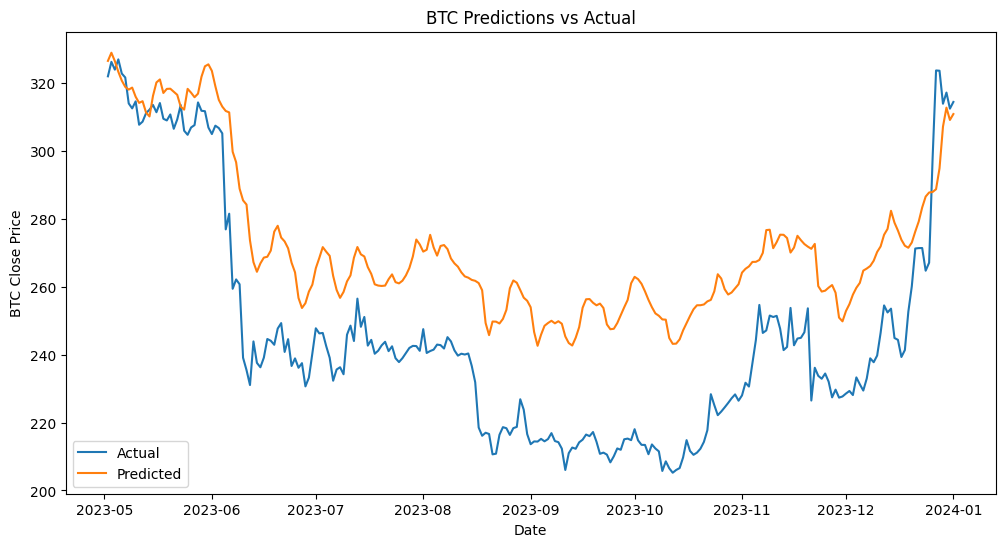

In [15]:
plt.figure(figsize=(12,6))
plt.plot(df_plot["Actual"], label="Actual")
plt.plot(df_plot["Predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("BTC Close Price")
plt.title("BTC Predictions vs Actual")
plt.legend()
plt.show()

## Every year 70%

### Preparing the train and test datasets

In [16]:
# Get unique years from your DataFrame index
years = bnb_df.index.year.unique()
print("Years in dataset:", years)

Years in dataset: Index([2021, 2022, 2023, 2024], dtype='int32', name='Date')


In [17]:
X_train_list = []
y_train_list = []

In [18]:
for year in years:
    # Filter data for this year
    bnb_year = bnb_df[bnb_df.index.year == year]

    # Calculate split index for 70%
    split_idx = int(len(bnb_year) * 0.7)

    # Take first 70% as training
    X_train_year = bnb_year.iloc[:split_idx, 1:].values  # all features except target column
    y_train_year = bnb_year.iloc[:split_idx, 0].values   # target column (e.g., next-day Close)

    # Append to lists
    X_train_list.append(X_train_year)
    y_train_list.append(y_train_year)

    print(f"Year {year}: {len(X_train_year)} train samples")

Year 2021: 129 train samples
Year 2022: 255 train samples
Year 2023: 255 train samples
Year 2024: 0 train samples


In [19]:
import numpy as np

# Stack all years’ train sets
X_train_combined = np.vstack(X_train_list)
y_train_combined = np.hstack(y_train_list)

print("Combined X_train shape:", X_train_combined.shape)
print("Combined y_train shape:", y_train_combined.shape)

Combined X_train shape: (639, 29)
Combined y_train shape: (639,)


In [20]:
X_test_list = []
y_test_list = []

In [21]:
for year in years:
    bnb_year = bnb_df[bnb_df.index.year == year]

    # Calculate split index (same as for train)
    split_idx = max(1, int(len(bnb_year) * 0.7))  # ensures at least 1 sample in train

    # Take the remaining 30% as test
    X_test_year = bnb_year.iloc[split_idx:, 1:].values   # features
    y_test_year = bnb_year.iloc[split_idx:, 0].values    # target

    # Append to test lists
    X_test_list.append(X_test_year)
    y_test_list.append(y_test_year)

    print(f"Year {year}: {len(X_test_year)} test samples")


Year 2021: 56 test samples
Year 2022: 110 test samples
Year 2023: 110 test samples
Year 2024: 0 test samples


In [22]:
import numpy as np

X_test_combined = np.vstack(X_test_list)
y_test_combined = np.hstack(y_test_list)

print("Combined X_test shape:", X_test_combined.shape)
print("Combined y_test shape:", y_test_combined.shape)

Combined X_test shape: (276, 29)
Combined y_test shape: (276,)


In [23]:
from sklearn.preprocessing import MinMaxScaler

# Initialize scalers
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

# Scale training data
X_train_scaled = x_scaler.fit_transform(X_train_combined)
y_train_scaled = y_scaler.fit_transform(y_train_combined.reshape(-1,1)).flatten()

In [24]:
import joblib

joblib.dump(x_scaler,"bnb_final_x_scaler.pkl")
joblib.dump(y_scaler,"bnb_final_y_scaler.pkl")

['bnb_final_y_scaler.pkl']

In [25]:
X_test_scaled = x_scaler.transform(X_test_combined)
y_test_scaled = y_scaler.transform(y_test_combined.reshape(-1,1)).flatten()

In [26]:
print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)
print("Scaled y_train shape:", y_train_scaled.shape)
print("Scaled y_test shape:", y_test_scaled.shape)

Scaled X_train shape: (639, 29)
Scaled X_test shape: (276, 29)
Scaled y_train shape: (639,)
Scaled y_test shape: (276,)


In [27]:
import numpy as np

def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])  # the next day after the sequence
    return np.array(X_seq), np.array(y_seq)

# Create sequences for train and test
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled)

# Check shapes
print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)

X_train_seq shape: (609, 30, 29)
y_train_seq shape: (609,)
X_test_seq shape: (246, 30, 29)
y_test_seq shape: (246,)


### Training the model

In [28]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [29]:
# Get number of features from the sequences
input_size = X_train_seq.shape[2]   # use the combined train sequences

# Initialize Bi-LSTM model
model_y = BiLSTM(input_size=input_size)

In [30]:
model_y = train_model(model_y, X_train_seq, y_train_seq, epochs=50, batch_size=32, lr=0.001)

c:\Users\tharu\anaconda3\envs\Streamlit\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [10/50], Loss: 0.004398
Epoch [20/50], Loss: 0.002872
Epoch [30/50], Loss: 0.001089
Epoch [40/50], Loss: 0.002141
Epoch [50/50], Loss: 0.000978


In [31]:
bnb_preds_ev_year =predict_model(model_y, X_test_seq)
bnb_preds_ev_year[:10]

array([[0.8777444 ],
       [0.8783355 ],
       [0.8988616 ],
       [0.9155563 ],
       [0.91089356],
       [0.88714075],
       [0.8686192 ],
       [0.8652602 ],
       [0.82144827],
       [0.79340094]], dtype=float32)

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict using the trained model
bnb_preds_ev_year = predict_model(model_y, X_test_seq)

# Inverse scale predictions to original price values
bnb_preds_actual = y_scaler.inverse_transform(bnb_preds_ev_year.reshape(-1,1))

# Inverse scale the test targets
bnb_y_test_actual = y_scaler.inverse_transform(y_test_seq.reshape(-1,1))

# Calculate metrics
mse = mean_squared_error(bnb_y_test_actual, bnb_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(bnb_y_test_actual, bnb_preds_actual)
r2 = r2_score(bnb_y_test_actual, bnb_preds_actual)
mape = np.mean(np.abs((bnb_y_test_actual - bnb_preds_actual) / bnb_y_test_actual)) * 100

# Print results
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MSE: 419.80
RMSE: 20.49
MAE: 11.03
R2 Score: 0.9525
MAPE: 3.91%


In [33]:
bnb_preds_actual = y_scaler.inverse_transform(bnb_preds_ev_year.reshape(-1, 1))

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Actual and predicted prices
actual_test_seq = y_scaler.inverse_transform(y_test_seq.reshape(-1,1)).flatten()
predicted_test_seq = bnb_preds_actual.flatten()

# Create DataFrame for plotting (no Date index)
df_bnb_plot_year = pd.DataFrame({
    "Actual": actual_test_seq,
    "Predicted": predicted_test_seq
})

# Display first few rows
df_bnb_plot_year.head()

,Actual,Predicted
0,589.256165,558.327026
1,579.689880,558.570374
2,607.592773,567.018982
3,571.648987,573.890625
4,552.966858,571.971436


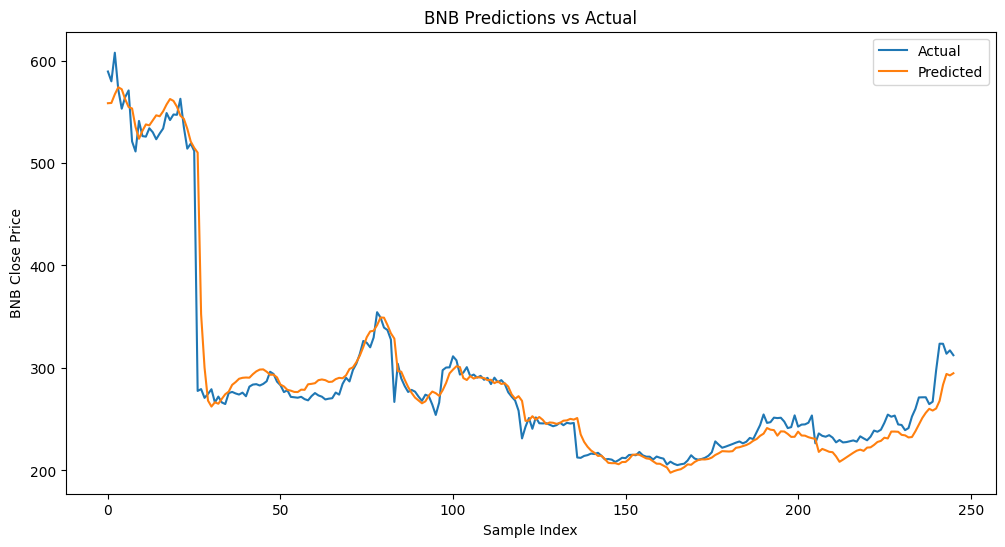

In [35]:
# Plot
plt.figure(figsize=(12,6))
plt.plot(df_bnb_plot_year["Actual"], label="Actual")
plt.plot(df_bnb_plot_year["Predicted"], label="Predicted")
plt.xlabel("Sample Index")
plt.ylabel("BNB Close Price")
plt.title("BNB Predictions vs Actual")
plt.legend()
plt.show()

## Three quarters train (all years-75%)

### train and test set preparation

In [36]:
# 75% train / 25% test split (time-based)
q3_split_idx = int(len(bnb_X) * 0.75)

bnb_q3_X_train = bnb_X.iloc[:q3_split_idx].values
bnb_q3_X_test  = bnb_X.iloc[q3_split_idx:].values

bnb_q3_y_train = bnb_y.iloc[:q3_split_idx].values
bnb_q3_y_test  = bnb_y.iloc[q3_split_idx:].values

# Shape checks
print("Q3 BNB X_train shape:", bnb_q3_X_train.shape)
print("Q3 BNB X_test shape:", bnb_q3_X_test.shape)
print("Q3 BNB y_train shape:", bnb_q3_y_train.shape)
print("Q3 BNB y_test shape:", bnb_q3_y_test.shape)

Q3 BNB X_train shape: (686, 29)
Q3 BNB X_test shape: (229, 29)
Q3 BNB y_train shape: (686,)
Q3 BNB y_test shape: (229,)


In [37]:
# Assuming btc_df has Date as index
bnb_q3_test_dates = bnb_df.index[-len(bnb_q3_X_test):]

print("Q3 test dates length:", len(bnb_q3_test_dates))

Q3 test dates length: 229


In [38]:
from sklearn.preprocessing import MinMaxScaler

# Feature scaler
bnb_q3_X_scaler = MinMaxScaler()

# Fit on TRAIN only
bnb_q3_X_train_scaled = bnb_q3_X_scaler.fit_transform(bnb_q3_X_train)

# Transform TEST using same scaler
bnb_q3_X_test_scaled = bnb_q3_X_scaler.transform(bnb_q3_X_test)

print("Q3 Scaled X_train shape:", bnb_q3_X_train_scaled.shape)
print("Q3 Scaled X_test shape:", bnb_q3_X_test_scaled.shape)


Q3 Scaled X_train shape: (686, 29)
Q3 Scaled X_test shape: (229, 29)


In [39]:
# Target scaler
bnb_q3_y_scaler = MinMaxScaler()

# Scale training target
bnb_q3_y_train_scaled = bnb_q3_y_scaler.fit_transform(
    bnb_q3_y_train.reshape(-1, 1)
).flatten()

# Scale test target
bnb_q3_y_test_scaled = bnb_q3_y_scaler.transform(
    bnb_q3_y_test.reshape(-1, 1)
).flatten()
14
print("Q3 Scaled y_train shape:", bnb_q3_y_train_scaled.shape)
print("Q3 Scaled y_test shape:", bnb_q3_y_test_scaled.shape)

Q3 Scaled y_train shape: (686,)
Q3 Scaled y_test shape: (229,)


In [40]:
import numpy as np

def create_sequences_q3(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i + time_steps])
        y_seq.append(y[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

In [41]:
# Create sequences (30-day window)
bnb_q3_X_train_seq, bnb_q3_y_train_seq = create_sequences_q3(
    bnb_q3_X_train_scaled,
    bnb_q3_y_train_scaled,
    time_steps=30
)

bnb_q3_X_test_seq, bnb_q3_y_test_seq = create_sequences_q3(
    bnb_q3_X_test_scaled,
    bnb_q3_y_test_scaled,
    time_steps=30
)

# Final shape checks
print("Q3 X_train_seq shape:", bnb_q3_X_train_seq.shape)
print("Q3 y_train_seq shape:", bnb_q3_y_train_seq.shape)
print("Q3 X_test_seq shape:", bnb_q3_X_test_seq.shape)
print("Q3 y_test_seq shape:", bnb_q3_y_test_seq.shape)


Q3 X_train_seq shape: (656, 30, 29)
Q3 y_train_seq shape: (656,)
Q3 X_test_seq shape: (199, 30, 29)
Q3 y_test_seq shape: (199,)


### Training the model 

In [42]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [43]:
# Get number of features
bnb_q3_input_size = bnb_q3_X_train_seq.shape[2]

# Initialize model
bnb_q3_model = BiLSTM(input_size=bnb_q3_input_size)

In [44]:
# Train model
bnb_q3_model = train_model(bnb_q3_model,bnb_q3_X_train_seq,bnb_q3_y_train_seq,epochs=50,batch_size=32,lr=0.001)

Epoch [10/50], Loss: 0.009476
Epoch [20/50], Loss: 0.002705
Epoch [30/50], Loss: 0.001749
Epoch [40/50], Loss: 0.002571
Epoch [50/50], Loss: 0.005532


In [45]:
# Generate predictions
bnb_q3_preds = predict_model(bnb_q3_model, bnb_q3_X_test_seq)

print("Q3 Predictions shape:", bnb_q3_preds.shape)
print("First 10 Q3 predictions:", bnb_q3_preds[:10])

Q3 Predictions shape: (199, 1)
First 10 Q3 predictions: [[0.09816212]
 [0.10495768]
 [0.12461007]
 [0.13111722]
 [0.1235527 ]
 [0.11600972]
 [0.10762287]
 [0.09775541]
 [0.08931467]
 [0.06471155]]


In [46]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict using the Q3 trained model
bnb_q3_preds_eval = predict_model(bnb_q3_model, bnb_q3_X_test_seq)

# Inverse scale predictions to original price values
bnb_q3_preds_actual = bnb_q3_y_scaler.inverse_transform(
    bnb_q3_preds_eval.reshape(-1, 1)
)

# Inverse scale the test targets
bnb_q3_y_test_actual = bnb_q3_y_scaler.inverse_transform(
    bnb_q3_y_test_seq.reshape(-1, 1)
)

# Calculate metrics
bnb_q3_mse = mean_squared_error(bnb_q3_y_test_actual, bnb_q3_preds_actual)
bnb_q3_rmse = np.sqrt(bnb_q3_mse)
bnb_q3_mae = mean_absolute_error(bnb_q3_y_test_actual, bnb_q3_preds_actual)
bnb_q3_r2 = r2_score(bnb_q3_y_test_actual, bnb_q3_preds_actual)
bnb_q3_mape = np.mean(np.abs((bnb_q3_y_test_actual - bnb_q3_preds_actual) / bnb_q3_y_test_actual)) * 100

# Print results
print(f"Q3 MSE: {bnb_q3_mse:.2f}")
print(f"Q3 RMSE: {bnb_q3_rmse:.2f}")
print(f"Q3 MAE: {bnb_q3_mae:.2f}")
print(f"Q3 R2 Score: {bnb_q3_r2:.4f}")
print(f"Q3 MAPE: {bnb_q3_mape:.2f}%")

Q3 MSE: 119.52
Q3 RMSE: 10.93
Q3 MAE: 7.63
Q3 R2 Score: 0.7445
Q3 MAPE: 3.13%


In [47]:
# Inverse scale predictions
bnb_q3_preds_actual = bnb_q3_y_scaler.inverse_transform(
    bnb_q3_preds.reshape(-1, 1)
)

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Align dates and values
bnb_q3_dates_seq = bnb_df.index[-len(bnb_q3_X_test):][30:]
bnb_q3_actual_seq = bnb_q3_y_test[30:]
bnb_q3_pred_seq = bnb_q3_preds_actual.flatten()

# Create DataFrame
bnb_q3_df_plot = pd.DataFrame({
    "Date": bnb_q3_dates_seq,
    "Actual": bnb_q3_actual_seq,
    "Predicted": bnb_q3_pred_seq
})

bnb_q3_df_plot.set_index("Date", inplace=True)
bnb_q3_df_plot.head(10)


,Actual,Predicted
Date,,
2023-06-17,244.610580,241.929779
2023-06-18,244.087265,245.037216
2023-06-19,242.903366,254.023682
2023-06-20,247.674438,256.999237
2023-06-21,249.286346,253.540207
2023-06-22,240.792435,250.090988
2023-06-23,244.564941,246.255920
2023-06-24,236.659653,241.743820
2023-06-25,238.892990,237.884109


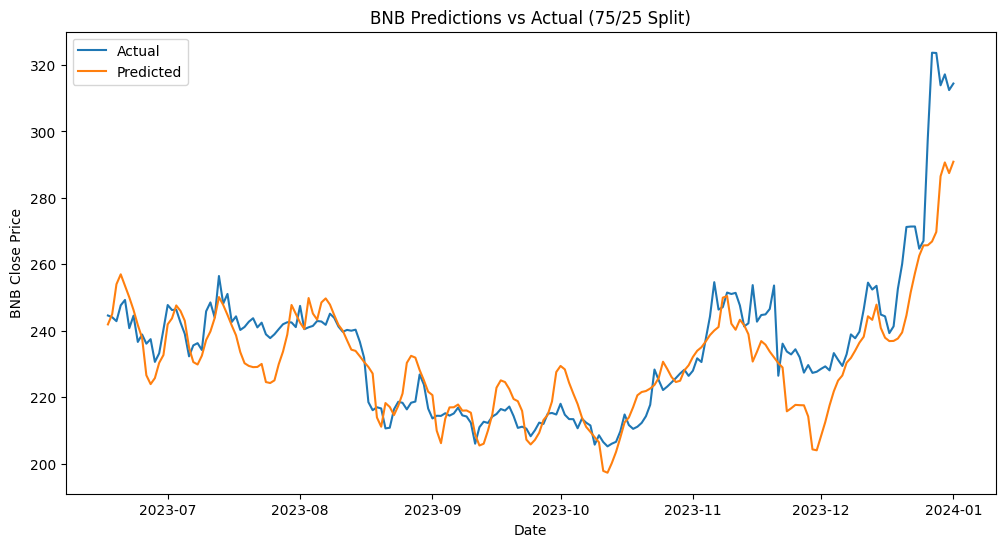

In [49]:
plt.figure(figsize=(12, 6))
plt.plot(bnb_q3_df_plot["Actual"], label="Actual")
plt.plot(bnb_q3_df_plot["Predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("BNB Close Price")
plt.title("BNB Predictions vs Actual (75/25 Split)")
plt.legend()
plt.show()

# Finetuning the models

In [50]:
import optuna

c:\Users\tharu\anaconda3\envs\Streamlit\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [51]:
from sklearn.model_selection import train_test_split

X_train_tune, X_val_tune, y_train_tune, y_val_tune = train_test_split(
    X_train_seq,
    y_train_seq,
    test_size=0.2,
    shuffle=False
)

In [52]:
import torch
import numpy as np

def objective(trial):

    # Hyperparameters to tune
    hidden_size = trial.suggest_int("hidden_size", 32, 128)
    num_layers = trial.suggest_int("num_layers", 1, 3)
    lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    # Get input size
    input_size = X_train_tune.shape[2]

    # Create model
    model = BiLSTM(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers
    )

    # Train model
    model = train_model(
        model,
        X_train_tune,
        y_train_tune,
        epochs=30,
        batch_size=batch_size,
        lr=lr
    )

    # Validation prediction
    preds = predict_model(model, X_val_tune)

    # Calculate validation MSE
    val_loss = np.mean((preds.flatten() - y_val_tune) ** 2)

    return val_loss

In [54]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)

[I 2026-04-14 22:49:24,863] A new study created in memory with name: no-name-26a8003a-92fc-4c0e-909b-511d0df880ce
C:\Users\tharu\AppData\Local\Temp\ipykernel_14380\3165717294.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)


Epoch [10/30], Loss: 0.008535
Epoch [20/30], Loss: 0.002144


[I 2026-04-14 22:50:15,171] Trial 0 finished with value: 0.0033768011235643844 and parameters: {'hidden_size': 80, 'num_layers': 2, 'lr': 0.001326503318813851, 'batch_size': 64}. Best is trial 0 with value: 0.0033768011235643844.


Epoch [30/30], Loss: 0.005210
Epoch [10/30], Loss: 0.004523
Epoch [20/30], Loss: 0.002595
Epoch [30/30], Loss: 0.003741


[I 2026-04-14 22:51:09,903] Trial 1 finished with value: 0.002800496998477623 and parameters: {'hidden_size': 86, 'num_layers': 2, 'lr': 0.0006160686519811344, 'batch_size': 64}. Best is trial 1 with value: 0.002800496998477623.


...

Epoch [30/30], Loss: 0.009429
Epoch [10/30], Loss: 0.008165
Epoch [20/30], Loss: 0.002144


[I 2026-04-14 22:56:54,443] Trial 8 finished with value: 0.0016888785911780126 and parameters: {'hidden_size': 59, 'num_layers': 3, 'lr': 0.0011028217861071847, 'batch_size': 64}. Best is trial 3 with value: 0.00041420651533311393.


Epoch [30/30], Loss: 0.001246
Epoch [10/30], Loss: 0.006425
Epoch [20/30], Loss: 0.006304


[I 2026-04-14 22:58:17,706] Trial 9 finished with value: 0.0022634762968192414 and parameters: {'hidden_size': 36, 'num_layers': 2, 'lr': 0.0025395948955620673, 'batch_size': 16}. Best is trial 3 with value: 0.00041420651533311393.


Epoch [30/30], Loss: 0.005253


In [55]:
print(study.best_params)

{'hidden_size': 107, 'num_layers': 1, 'lr': 0.0013949192871148132, 'batch_size': 32}


In [56]:
import optuna.visualization as vis

vis.plot_optimization_history(study)

In [57]:
vis.plot_param_importances(study)

In [58]:
vis.plot_parallel_coordinate(study)

In [59]:
# Best parameters from Optuna
best_params = study.best_params

# Get input size
input_size = X_train_seq.shape[2]

# Create final tuned model
model_tuned = BiLSTM(
    input_size=input_size,
    hidden_size=best_params["hidden_size"],
    num_layers=best_params["num_layers"]
)

# Train final model on full training data
model_tuned = train_model(
    model_tuned,
    X_train_seq,
    y_train_seq,
    epochs=50,
    batch_size=best_params["batch_size"],
    lr=best_params["lr"]
)

c:\Users\tharu\anaconda3\envs\Streamlit\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning:

Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.



Epoch [10/50], Loss: 0.001738
Epoch [20/50], Loss: 0.003263
Epoch [30/50], Loss: 0.001770
Epoch [40/50], Loss: 0.000810
Epoch [50/50], Loss: 0.001924


In [60]:
bnb_preds_tuned = predict_model(model_tuned, X_test_seq)
bnb_preds_tuned[:10]

array([[0.82593936],
       [0.81631297],
       [0.85175586],
       [0.87913394],
       [0.8760904 ],
       [0.84443706],
       [0.8203691 ],
       [0.8144975 ],
       [0.77122   ],
       [0.733477  ]], dtype=float32)

In [61]:
bnb_preds_tuned_actual = y_scaler.inverse_transform(bnb_preds_tuned.reshape(-1,1))

In [62]:
bnb_y_test_actual = y_scaler.inverse_transform(y_test_seq.reshape(-1,1))

In [63]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(bnb_y_test_actual, bnb_preds_tuned_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(bnb_y_test_actual, bnb_preds_tuned_actual)
r2 = r2_score(bnb_y_test_actual, bnb_preds_tuned_actual)
mape = np.mean(np.abs((bnb_y_test_actual - bnb_preds_tuned_actual) / bnb_y_test_actual)) * 100

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MSE: 436.45
RMSE: 20.89
MAE: 13.73
R2 Score: 0.9506
MAPE: 4.91%


# Saving the best performed model

In [65]:
torch.save(model_tuned.state_dict(), "Binance_Final.pth")